In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit, RawFeatureVector

algorithm_globals.random_seed = 42

In [2]:
# Amplitude encoding with a large vector
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation

In [4]:
 sample_pca_reduced_df = pd.read_csv(r"X_pca_df800.csv")

In [5]:
sample_pca_reduced_df.shape

(800, 64)

In [6]:
sample_pca_reduced_df.head(2)

,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,...,pca_54,pca_55,pca_56,pca_57,pca_58,pca_59,pca_60,pca_61,pca_62,pca_63
0,-20.244039,-6.718547,-11.839866,3.007421,4.245244,-3.932463,0.380121,-3.792199,-0.324690,1.13084,...,-4.263460,-3.183433,3.756453,1.945535,-0.347829,-0.425930,3.166405,-2.446840,-1.412551,1.460386
1,39.612205,-9.017961,-9.869754,7.911266,-12.857755,-0.139605,-9.189059,14.995977,-8.147701,-9.10158,...,-1.818266,-7.895065,-1.943329,1.922069,4.046929,-1.499064,4.023561,7.101501,-0.294733,-0.920286


In [7]:
X_pca = sample_pca_reduced_df.values.astype(float)
X_pca

array([[-20.24403853,  -6.71854693, -11.83986608, ...,  -2.44684049,
         -1.41255105,   1.46038581],
       [ 39.6122053 ,  -9.01796079,  -9.86975353, ...,   7.10150119,
         -0.29473323,  -0.92028645],
       [ -0.9490618 ,  -8.58692863,  10.02665469, ...,   1.87479011,
        -10.83935942,  -0.53568017],
       ...,
       [-17.94227216,  -9.20516314,  -7.49908326, ...,  -5.03717339,
         -3.08102528,   3.80613596],
       [-15.9256278 ,  -9.42942039,  -2.79996573, ...,  -2.79295559,
          2.06066621,   1.41199974],
       [  2.87495928,  35.62286603,   3.99863337, ...,  -0.56846159,
         -1.96584731,   1.34571882]])

In [8]:
# create array of shape (800,2) as the labels (positive [1,0], and negative [0,1])
num_samples = 400
y_one_hot = np.array([[0, 1]] * num_samples + [[1, 0]] * num_samples)
print(y_one_hot.shape)
print(y_one_hot[0:2])
print(y_one_hot[-2:])

(800, 2)
[[0 1]
 [0 1]]
[[1 0]
 [1 0]]


In [8]:
def pad_to_power_of_2(data):
    """Pad data with zeros to the nearest power of 2"""
    next_power = 2 ** int(np.ceil(np.log2(len(data))))
    padded_data = np.zeros(next_power)
    padded_data[:len(data)] = data  # Retaining original values
    return padded_data

In [31]:
X_iso

array([[-1.53629818e+01, -3.37232433e+01, -4.83259836e+01, ...,
        -5.64459116e+00, -3.04108789e+01, -2.17341996e+01],
       [-9.10263677e+01, -7.98334264e+01,  1.26731686e-01, ...,
        -1.33300070e+00,  7.41104594e+01, -2.01963136e+01],
       [-7.30796256e+01, -4.82663794e+00, -2.05729668e+01, ...,
        -7.39577115e-01, -2.74852927e+00, -1.46819707e-01],
       ...,
       [ 4.96191575e+02, -1.95547733e+02, -9.25988170e+01, ...,
        -5.62076881e+00,  3.19648723e+00, -3.42108526e+01],
       [ 2.94468220e+02,  1.90603966e+02, -1.39499011e+02, ...,
        -5.12632707e+01, -1.76959532e+01, -5.86563215e+00],
       [-6.83402496e+01, -4.63795014e+00, -1.88254468e+01, ...,
        -2.83643211e+00, -4.78856922e+00,  7.10067595e-01]])

In [9]:
# normalizing the training dataset for RawFeatureVector
from numpy.linalg import norm

def normalize(X):
    return np.array([x / norm(x) if norm(x) > 0 else x for x in X])

X_train_norm = normalize(X_pca)

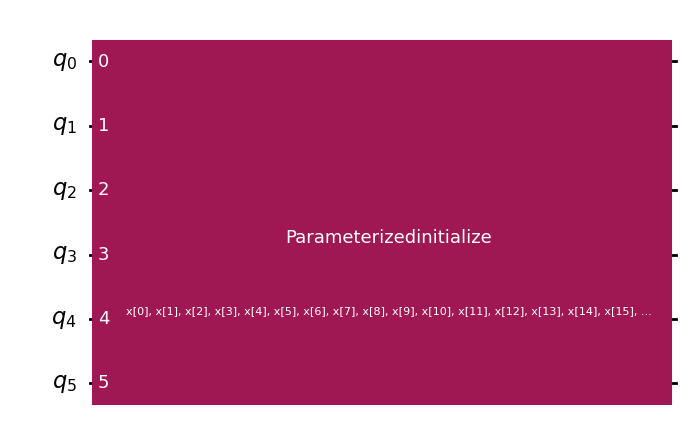

In [10]:
num_features = 64
feature_map = RawFeatureVector(num_features)
display(feature_map.draw(output="mpl"))

In [11]:
# callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()


In [18]:
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()


In [21]:
# construct ansatz, and optimizer
from qiskit.circuit.library import TwoLocal
ansatz = TwoLocal(num_qubits=6, rotation_blocks="ry", entanglement_blocks="cz", reps=1)

In [22]:
# construct variational quantum classifier
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    loss="cross_entropy",
    optimizer=COBYLA(maxiter=30),
    callback=callback_graph,
    sampler=sampler,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


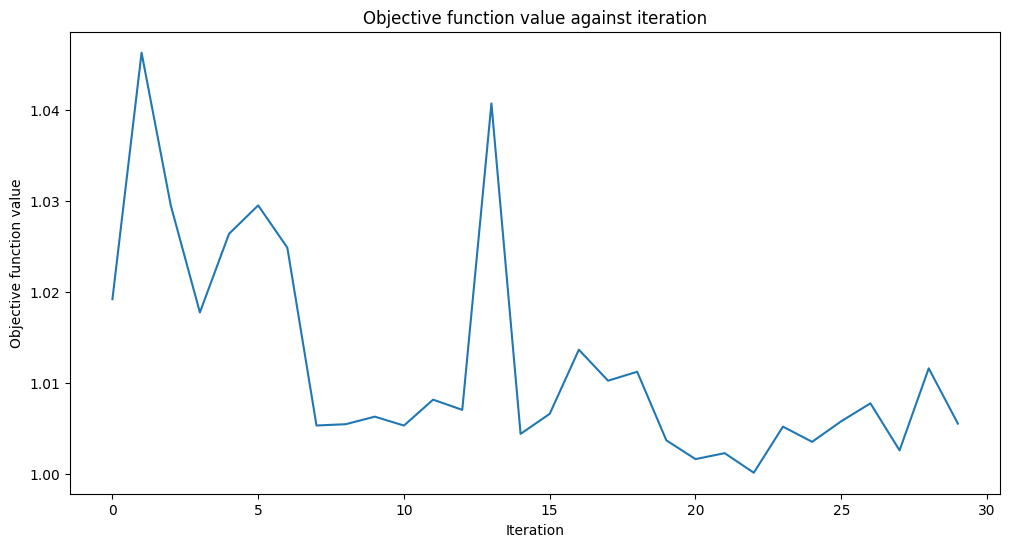

In [23]:
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to data
vqc.fit(X_train_norm, y_one_hot)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)


In [49]:
# score classifier
vqc.score(X_train_norm, y_one_hot)
# evaluate data points
y_predict = vqc.predict(X_train_norm)

In [54]:
from sklearn.metrics import accuracy_score

# Predict labels for the training set
y_pred = np.argmax(y_predict, axis=1)

# Convert one-hot encoded `y_one_hot` back to class labels
y_true = np.argmax(y_one_hot, axis=1)

# Compute accuracy
acc = accuracy_score(y_true, y_pred)
print("Training Accuracy:", acc)


Training Accuracy: 0.5425


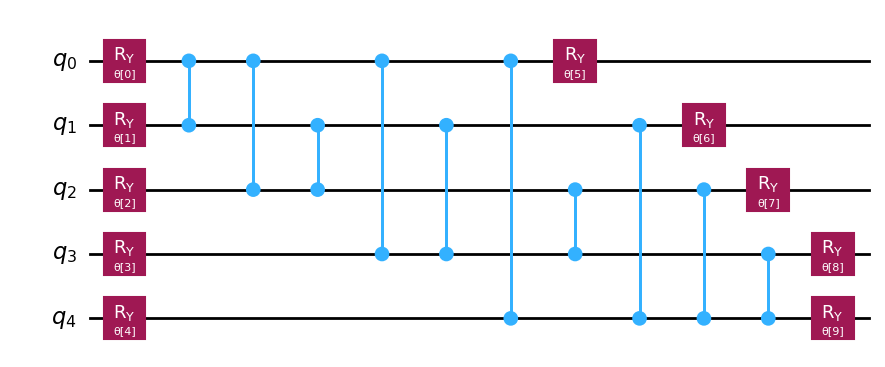

In [55]:
vqc.ansatz.decompose().draw("mpl")